# 1) Optimization via Gradient Descent

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## 1.1) Write a script that implement the GD algorithm

**NOTE**: it backtraks if the learning rate is not given, it doesn't otherwise

In [2]:
def backtracking(f, grad_f, x):
    """
    This function is a simple implementation of the backtracking algorithm for
    the GD (Gradient Descent) method.
    
    f: function. The function that we want to optimize.
    grad_f: function. The gradient of f(x).
    x: ndarray. The actual iterate x_k.
    """
    alpha = 1
    c = 0.8
    tau = 0.25
    
    while f(x - alpha * grad_f(x)) > f(x) - c * alpha * np.linalg.norm(grad_f(x), 2) ** 2:
        alpha = tau * alpha
        
        if alpha < 1e-3:
            break
    return alpha

In [3]:
def GD(f,                           # Function we want to optimize
       grad_f,                      # Gradient
       x0,                          # Starting point
       kmax,                        # Maximum number of iterations
       tolx,                        # The relative tolerance of the algorithm
       tolf,                        # The tolerance for the gradient norm
       alpha=None                   # Learning rate (optional)
    ) -> tuple:
    '''
    Gradient Descent (GD) Optimization Algorithm.
    
    This function performs gradient descent optimization to find a local minimum 
    of a given function `f`, starting from an initial point `x0`. It iterates until 
    the maximum number of iterations `kmax` is reached, or one of the stopping 
    criteria (`tolx` or `tolf`) is satisfied.

    Parameters:
    ----------
    f : callable
        The objective function to be minimized. It should accept an array-like 
        input and return a scalar.
    grad_f : callable
        The gradient of the objective function. It should accept an array-like input 
        and return a gradient vector.
    x0 : array-like
        The starting point for the optimization.
    kmax : int
        Maximum number of iterations allowed.
    tolx : float
        Stopping tolerance for the relative change in position. 
    tolf : float
        Stopping tolerance for the gradient norm. 
    alpha : float or None, optional
        The learning rate for gradient descent. If `None`, backtracking line search 
        is used to determine the step size dynamically.

    Returns:
    -------
    tuple
        A tuple containing:
        - `x` (ndarray): The array of iterates, where each row represents the 
          position at a given iteration.
        - `num_iterations` (int): The total number of iterations performed. 
        - `f_val` (ndarray): The array of function values at each iteration.
        - `grads` (ndarray): The array of gradients at each iteration.
        - `err` (ndarray): The array of gradient norms at each iteration.
    '''

    # If alpha is not given we backtrack
    backtracking_enabled = (alpha is None)
    
    # Iniizialize the containers
    x, f_val, grads, err = [], [], [], []
    
    # Pass actual value to next iteration
    x_old = x0
    
    for k in range(kmax):
        # Update containers
        x.append(x_old)
        f_val.append(f(x_old))
        grads.append(grad_f(x_old))
        err.append(np.linalg.norm(grads[-1], 2))
        
        # Compute backtracking
        if backtracking_enabled: 
            alpha = backtracking(f, grad_f, x_old)
        
        # Compute the new value
        x_k = x_old - alpha * grad_f(x_old)
        
        # Check the stop condition
        if np.linalg.norm(grad_f(x_k), 2) <= tolf * np.linalg.norm(grad_f(x0), 2):
            break
        if np.linalg.norm(x_k - x_old, 2) <= tolx:
            break
        
        # Pass actual value to next iteration
        x_old = x_k
    
    return np.array(x), k+1, np.array(f_val), np.array(grads), np.array(err)

## 1.2) Test the algorithm above on the following functions
- For each of the functions above, test the GD method with and without backtracking, trying different values for the step size $\alpha > 0$ when backtracking is not employed. Comment on the results.
- Plot the value of $||\nabla f(x_k)||_2$ as a function of $k$, check that it goes to zero, and compare the convergence speed (in terms of the number of iterations $k$) for the different values of 
$\alpha > 0$ and with backtracking.
- For each of the points above, use:
    - `x0` $ = (0,0,...,0)^T$ 
    - `kmax` $ = 100$ 
    - `kmax` = `kmax` = `1e-5` 
- For functions 1 and 2, show the contour plot around the true minimum and visualize the path described by the iterations, i.e. representing on the contour plot the position of each iterate computed by the GD algorithm. See the `plt.contour` documentation.

In [4]:
def plot_gradient_norm_and_xtrue(x, x_sol, err, k, x_true, 
                                title1, label1, ax1, 
                                title2=None, label2=None, ax2=None, one_dim=False):
    # Gradient norm plot
    ax1.plot(err, label=label1)
    ax1.set_title(title1)
    ax1.set_ylabel(r"$\|\nabla f_{x_k}\|_2$")
    ax1.set_xlabel("Num iterations")
    ax1.set_yscale("log")
    ax1.legend()
    ax1.grid(True)

    if label2 is not None:
        # Distance from x_true plot
        if one_dim:
            ax2.plot(np.abs(x - x_true), label=label2)
        else:
            ax2.plot(np.linalg.norm(x - x_true, axis=1), label=label2)
        ax2.set_title(title2)
        ax2.set_ylabel(r'$\|x_k - x^*\|_2$')
        ax2.set_xlabel("Num iterations")
        ax2.set_yscale("log")
        ax2.legend()
        ax2.grid(True)
    
def plot_search(f, grad_f, x0, kmax, tolx, tolf, alpha=None, margin_percentage=0.2, x_true=None):
    # Compute the search
    x, k, f_val, grads, err = GD(f, grad_f, x0, kmax, tolx, tolf, alpha)
    
    # GLOBAL plot
    X1, X2 = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-2, 5, 100))
    Y = f((X1, X2))
    plt.figure(figsize=(10, 6))
    cp = plt.contour(X1, X2, Y, colors='white')
    plt.clabel(cp, inline=1, fontsize=10)
    cp = plt.contourf(X1, X2, Y, alpha=0.75)
    plt.xlabel(r'$x_1$')
    plt.ylabel(r'$x_2$')
    plt.plot(x[:, 0], x[:, 1], label="Path")
    plt.plot(x[:, 0], x[:, 1], '*', label="Steps")
    if x_true is not None:
        plt.plot(x_true[0], x_true[1], 'ro', label="True Solution", markersize=10)
    plt.legend()
    plt.title("Global View")
    plt.colorbar(cp)
    plt.show()

    # Plots the zoom of the path only if the solution is considered "reached"
    if (k!=kmax):
        # ZOOMED plot (% zoom)
        x_range = np.max(x[:, 0]) - np.min(x[:, 0])
        y_range = np.max(x[:, 1]) - np.min(x[:, 1])
        x_min = np.min(x[:, 0]) - margin_percentage * x_range
        x_max = np.max(x[:, 0]) + margin_percentage * x_range
        y_min = np.min(x[:, 1]) - margin_percentage * y_range
        y_max = np.max(x[:, 1]) + margin_percentage * y_range
        X1_zoom, X2_zoom = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
        Y_zoom = f((X1_zoom, X2_zoom))
        plt.figure(figsize=(10, 6))
        cp = plt.contour(X1_zoom, X2_zoom, Y_zoom, colors='white')
        plt.clabel(cp, inline=1, fontsize=10)
        cp = plt.contourf(X1_zoom, X2_zoom, Y_zoom, alpha=0.75)
        plt.xlabel(r'$x_1$')
        plt.ylabel(r'$x_2$')
        plt.plot(x[:, 0], x[:, 1], label="Path")
        plt.plot(x[:, 0], x[:, 1], '*', label="Steps")
        if x_true is not None:
            plt.plot(x_true[0], x_true[1], 'ro', label="True Solution", markersize=10)
        plt.legend()
        plt.title("Zoomed View")
        plt.colorbar(cp)
        plt.show()

### 1.2.1) $f(x_1, x_2)=(x_1-3)^2+(x_2-1)^2$
The true optimum is $x^{*}=(3,1)^T$


In [5]:
def f(x):
    x1 = x[0]
    x2 = x[1]
    return (x1 - 3)**2 + (x2 - 1)**2
def grad_f(x):
    x1 = x[0]
    x2 = x[1]
    return np.array([2*(x1 - 3), 2*(x2 - 1)])

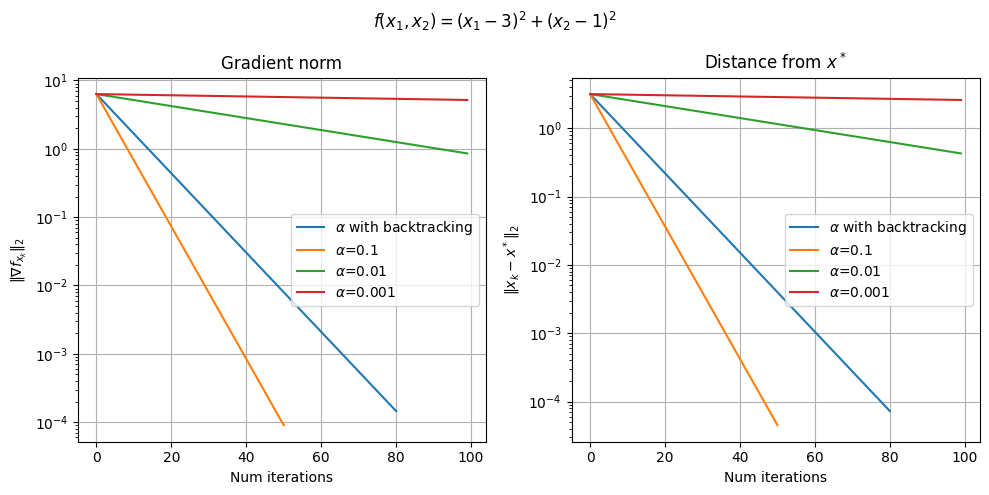

In [6]:
f_name = '$f(x_1, x_2) = (x_1-3)^2+(x_2-1)^2$'
x_true = np.array([3,1])
x0 = np.array([0, 0])
kmax = 100
tolf = tolx = 1e-5

cols = 2
rows = 1  
fig, axes = plt.subplots(rows, cols, figsize=(10,5))
fig.suptitle(f_name)
axes = axes.flatten()

#### WITH BACKTRACKING ##########################################################
x, k, f_val, grads, err = GD(f, grad_f, x0, kmax, tolx, tolf)
plot_gradient_norm_and_xtrue(
    x, x[-1], err, k, x_true, 
    title1=rf"Gradient norm",
    label1=rf"$\alpha$ with backtracking", ax1=axes[0],
    title2=rf"Distance from $x^*$",
    label2=rf"$\alpha$ with backtracking", ax2=axes[1]
)

#### WITHOUT BACKTRACKING #######################################################
alphas = [0.1, 0.01, 0.001]
for i, alpha in enumerate(alphas):
    x, k, f_val, grads, err = GD(f, grad_f, x0, kmax, tolx, tolf, alpha=alpha)
    plot_gradient_norm_and_xtrue(
        x, x[-1], err, k, x_true, 
        title1=rf"Gradient norm",
        label1=rf"$\alpha$={alpha}", ax1=axes[0],
        title2=rf"Distance from $x^*$",
        label2=rf"$\alpha$={alpha}", ax2=axes[1]
    )  

plt.tight_layout()
plt.show()

#### Plot search with fixed alpha

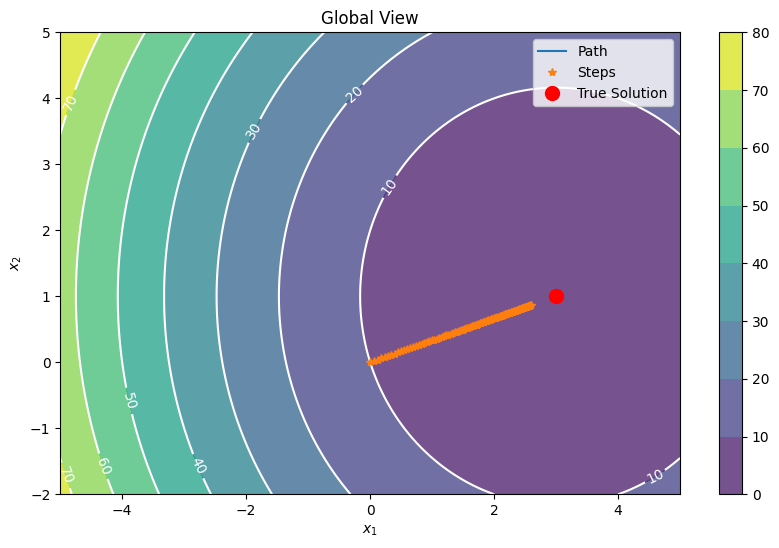

In [7]:
alpha=0.01
plot_search(f, grad_f, x0, kmax, tolx, tolf, alpha, margin_percentage=0.1, x_true=x_true)

#### Plot search with backtracking alpha

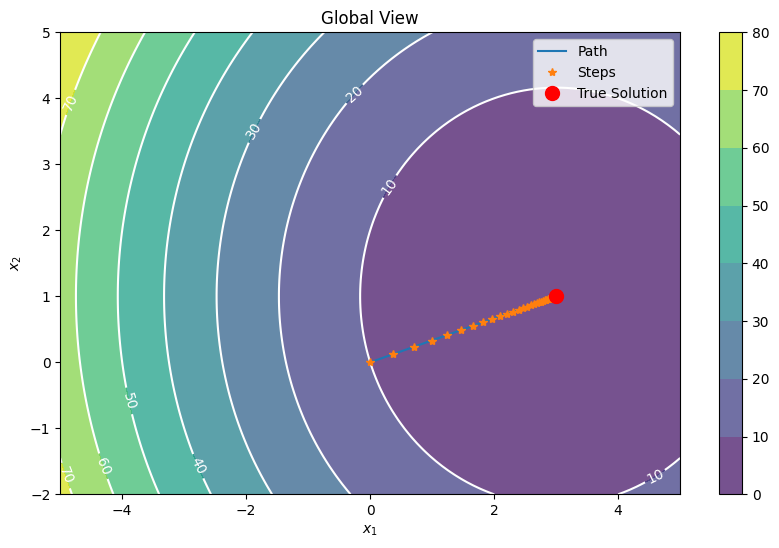

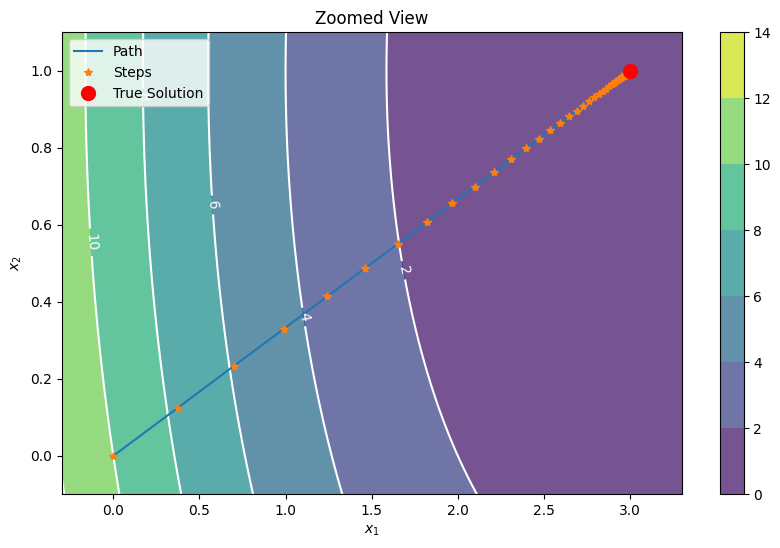

In [8]:
plot_search(f, grad_f, x0, kmax, tolx, tolf, margin_percentage=0.1, x_true=x_true)

### 1.2.2) $f(x_1, x_2)=10(x_1-1)^2+(x_2-2)^2$
The true optimum is $x^{*}=(1,2)^T$


In [9]:
def f(x):
    x1 = x[0]
    x2 = x[1]
    return 10 * ((x1 - 1)**2) + (x2 - 2)**2
def grad_f(x):
    x1 = x[0]
    x2 = x[1]
    return np.array([20*(x1 - 1), 2*(x2 - 2)])

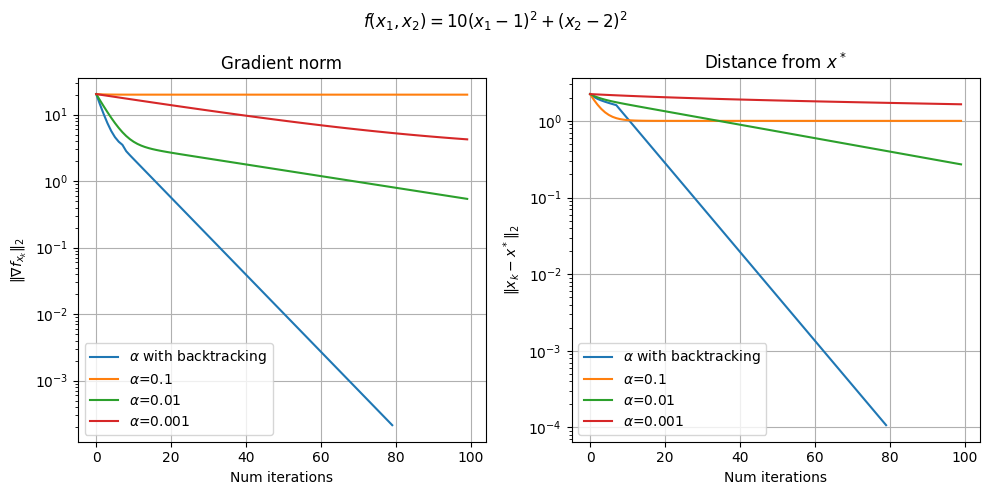

In [10]:
f_name='$f(x_1, x_2) = 10(x_1-1)^2+(x_2-2)^2$'
x_true =np.array([1,2])
x0 = np.array([0, 0])
kmax = 100
tolf = tolx = 1e-5

cols = 2
rows = 1   
fig, axes = plt.subplots(rows, cols, figsize=(10,5))
fig.suptitle(f_name)
axes = axes.flatten()

#### WITH BACKTRACKING ##########################################################
x, k, f_val, grads, err = GD(f, grad_f, x0, kmax, tolx, tolf)
plot_gradient_norm_and_xtrue(
    x, x[-1], err, k, x_true, 
    title1=rf"Gradient norm",
    label1=rf"$\alpha$ with backtracking", ax1=axes[0],
    title2=rf"Distance from $x^*$",
    label2=rf"$\alpha$ with backtracking", ax2=axes[1]
)

#### WITHOUT BACKTRACKING #######################################################
alphas = [0.1, 0.01, 0.001]
for i, alpha in enumerate(alphas):
    x, k, f_val, grads, err = GD(f, grad_f, x0, kmax, tolx, tolf, alpha=alpha)
    plot_gradient_norm_and_xtrue(
        x, x[-1], err, k, x_true, 
        title1=rf"Gradient norm",
        label1=rf"$\alpha$={alpha}", ax1=axes[0],
        title2=rf"Distance from $x^*$",
        label2=rf"$\alpha$={alpha}", ax2=axes[1]
    )
    
plt.tight_layout()
plt.show()

#### Plot search with fixed alpha

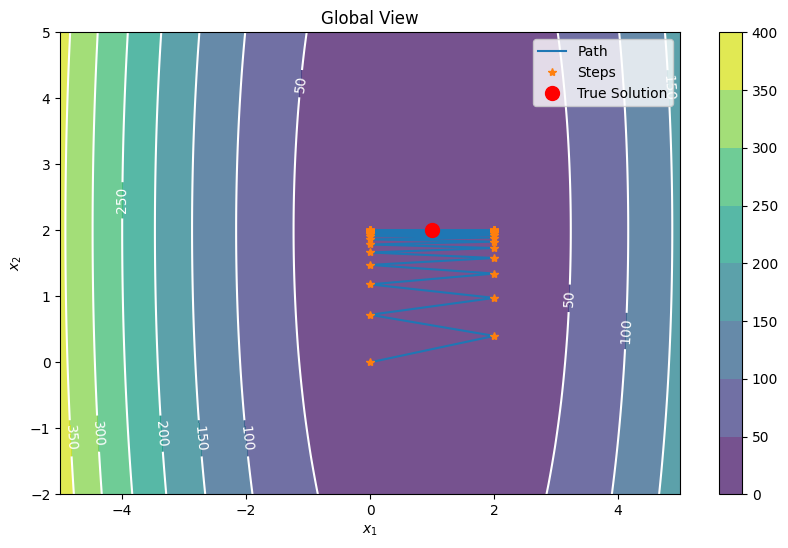

In [11]:
alpha=0.1
plot_search(f, grad_f, x0, kmax, tolx, tolf, alpha, margin_percentage=0.1, x_true=x_true)

#### Plot search with backtracking alpha

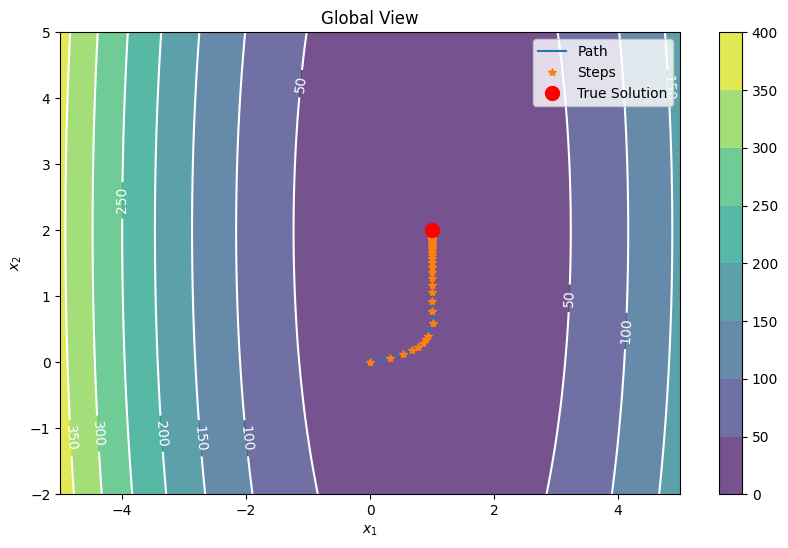

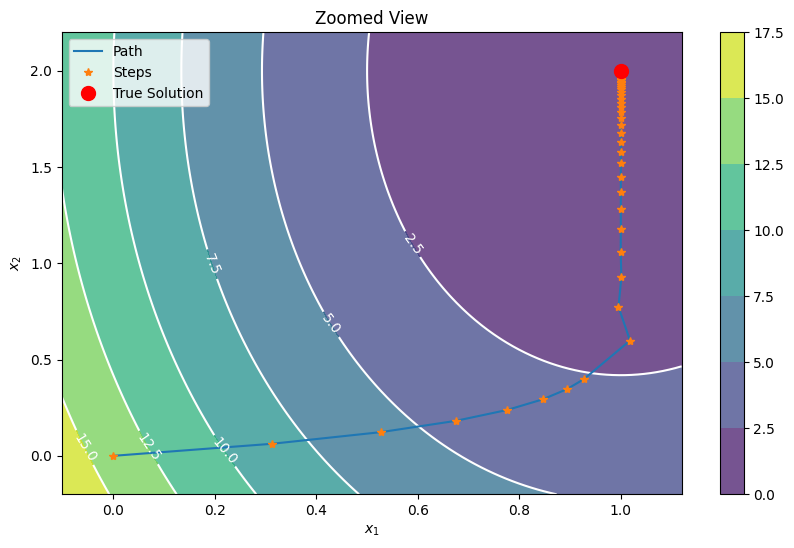

In [12]:
plot_search(f, grad_f, x0, kmax, tolx, tolf, margin_percentage=0.1, x_true=x_true)

### 1.2.3) $f(x)=\frac{1}{2}||Ax-b||_2^2$

Where $A \in \mathbf{R}^{n \times n}$ is the Vandermonde matrix associated with the vector $v \in \mathbf{R}^n$ that contains $n$ equispaced values in the interval $[0,1]$, and $b \in \mathbf{R}^n$ is computed by first setting $x^* = (1,1,...,1)^T$, and then $b=Ax^*$. Try for different values of $n$ (e.g. $n=5,10,15, ...$)

The true optimum is $x_{true} = [1,1,...,1]^T$

In [13]:
def f(x):
    v = np.linspace(0, 1, x.shape[0])
    A = np.vander(v, increasing=True)  
    x_true = np.ones(v.shape[0])  
    b = A @ x_true
    return 0.5 * np.linalg.norm(A @ x - b)**2

def grad_f(x):
    v = np.linspace(0, 1, x.shape[0])
    A = np.vander(v, increasing=True)  
    x_true = np.ones(v.shape[0])  
    b = A @ x_true
    res = A.T @ (A @ x - b)  
    return res


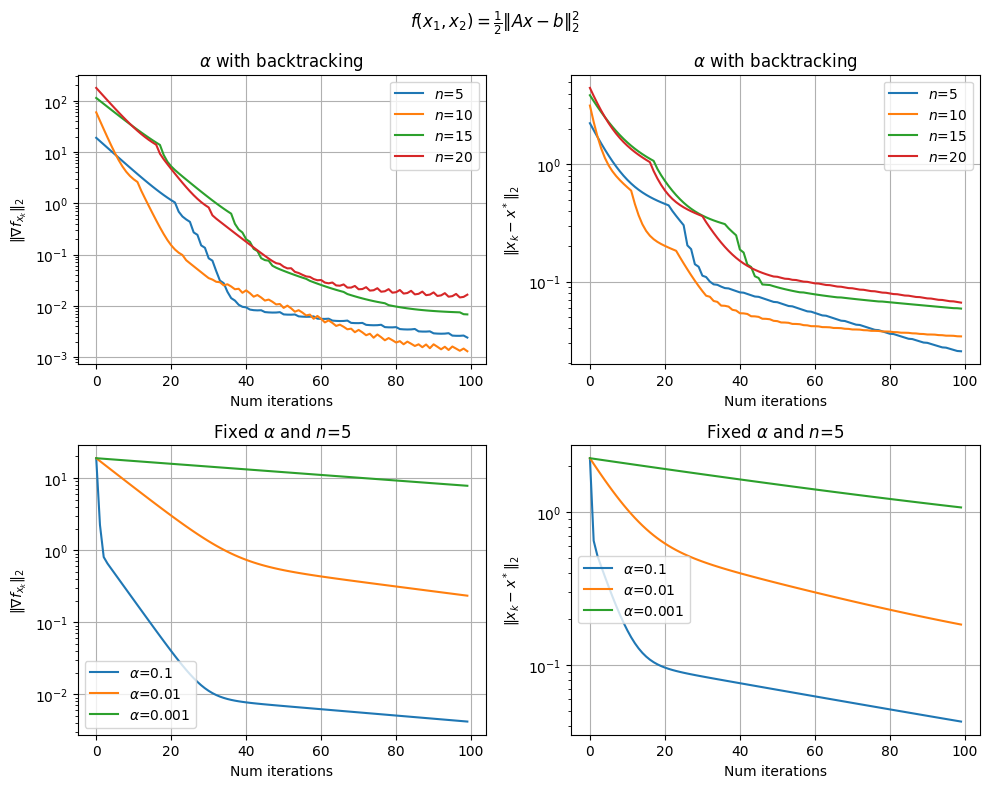

In [14]:
f_name = '$f(x_1, x_2) = \\frac{1}{2}\|Ax-b\|^2_2$'

fig, axes = plt.subplots(2, 2, figsize=[10, 8])
fig.suptitle(f_name)
axes = axes.flatten()
for ax in axes: 
    ax.set_yscale("log")

#### WITH BACKTRACKING ##########################################################
Ns = (5, 10, 15, 20)

for i, n in enumerate(Ns):
    x0 = np.array(np.zeros((n,)))
    x_true = np.array(np.ones((n,)))
    kmax = 100
    tolf = tolx = 1e-5
    
    x, k, f_val, grads, err = GD(f, grad_f, x0, kmax, tolx, tolf)
    plot_gradient_norm_and_xtrue(
        x, x[-1], err, k, x_true, 
        title1=r"$\alpha$ with backtracking",
        label1=rf"$n$={n}", ax1=axes[0],
        title2=r"$\alpha$ with backtracking",
        label2=rf"$n$={n}", ax2=axes[1]
    )    
    
#### WITHOUT BACKTRACKING #######################################################
N = 5
x0 = np.array(np.zeros((N,)))
x_true = np.array(np.ones((N,)))
alphas = (0.1, 0.01, 0.001)

for i, alpha in enumerate(alphas):
    x, k, f_val, grads, err = GD(f, grad_f, x0, kmax, tolx, tolf, alpha=alpha)
    plot_gradient_norm_and_xtrue(
        x, x[-1], err, k, x_true, 
        title1=rf"Fixed $\alpha$ and $n$={N}",
        label1=rf"$\alpha$={alpha}", ax1=axes[2],
        title2=rf"Fixed $\alpha$ and $n$={N}",
        label2=rf"$\alpha$={alpha}", ax2=axes[3]
    )
    
plt.tight_layout()
plt.show()

### 1.2.4) $f(x)=\frac{1}{2}||Ax-b||_2^2 + \frac{\lambda}{2}||x||_2^2$

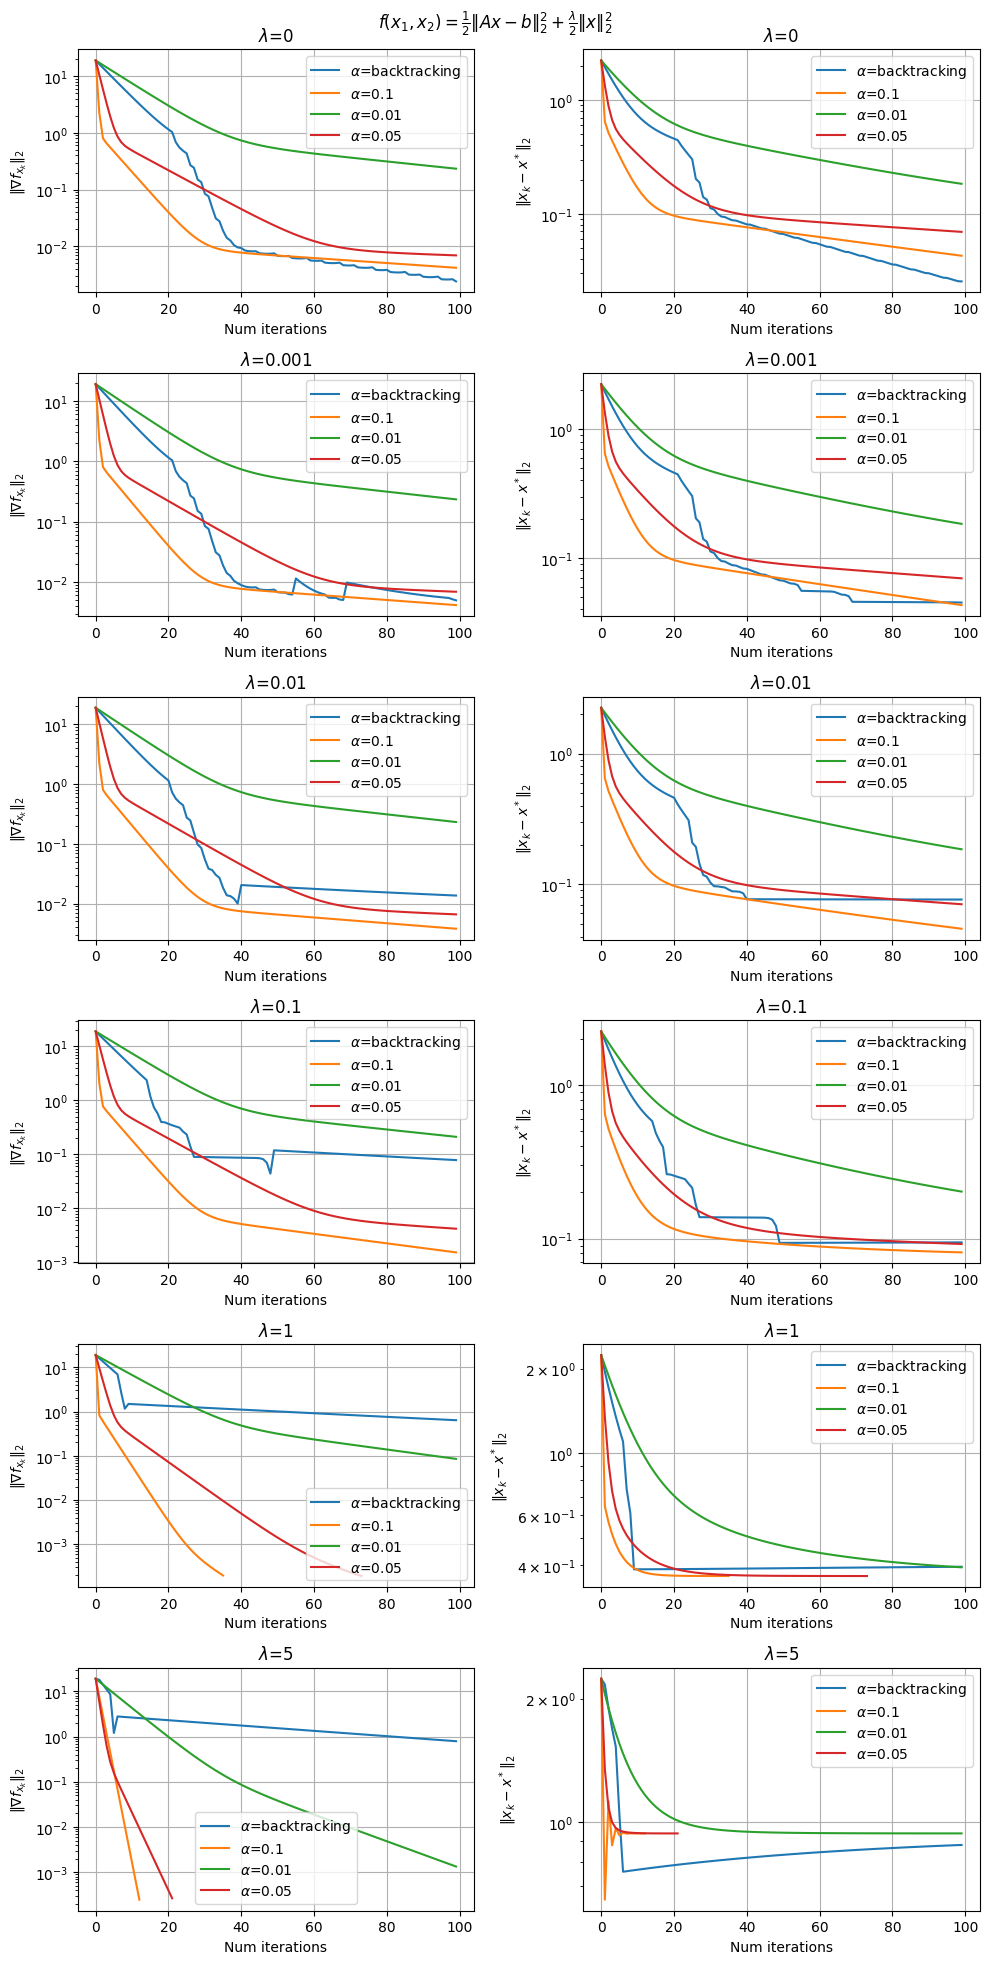

In [15]:
f_name = '$f(x_1, x_2) = \\frac{1}{2}\|Ax-b\|^2_2+\\frac{\lambda}{2}\|x\|^2_2$'

LAMBDAs = [0, 0.001, 0.01, 0.1, 1, 5]
alphas = [0.1, 0.01, 0.05]
N=5
x0 = np.array(np.zeros((N,)))
kmax = 100
tolf = tolx = 1e-5

n = len(LAMBDAs)
    
# SQUARE DISPOSITION
cols = 2
rows = int(np.ceil(2*n / cols)) 
fig, axes = plt.subplots(rows, cols, figsize=(10,20))
fig.suptitle(f_name)
axes = axes.flatten()

for i, LAMBDA in enumerate(LAMBDAs):

    # Put here the functions in order not to redefine them
    def f(x):
        v = np.linspace(0, 1, x.shape[0])
        A = np.vander(v)
        x_true = np.ones((v.shape[0],)).T
        b = A @ x_true 
        lmbda = LAMBDA
        return 0.5 * np.linalg.norm(A@x - b)**2 + lmbda/2*np.linalg.norm(x)

    def grad_f(x):
        v = np.linspace(0, 1, x.shape[0])
        A = np.vander(v)
        x_true = np.ones((v.shape[0],)).T
        b = A @ x_true 
        lmbda = LAMBDA
        res = A.T@(A@x - b) + lmbda*x
        return res 
    
    #### WITH BACKTRACKING ##########################################################
    x, k, f_val, grads, err = GD(f, grad_f, x0, kmax, tolx, tolf)
    plot_gradient_norm_and_xtrue(
        x, x[-1], err, k, x_true, 
        title1=rf"$\lambda$={LAMBDA}",
        label1=rf"$\alpha$=backtracking", ax1=axes[2*i],
        title2=rf"$\lambda$={LAMBDA}",
        label2=rf"$\alpha$=backtracking", ax2=axes[2*i+1]
    )

    #### WITHOUT BACKTRACKING #######################################################
    for alpha in alphas:
        x, k, f_val, grads, err = GD(f, grad_f, x0, kmax, tolx, tolf, alpha=alpha)
        plot_gradient_norm_and_xtrue(
            x, x[-1], err, k, x_true, 
            title1=rf"$\lambda$={LAMBDA}",
            label1=rf"$\alpha$={alpha}", ax1=axes[2*i],
            title2=rf"$\lambda$={LAMBDA}",
            label2=rf"$\alpha$={alpha}", ax2=axes[2*i+1]
        )
    
plt.tight_layout()
plt.show()

### 1.2.5) $f(x) = x^4 + x^3 -2x^2 -2x$

#### Function adaption to one dimension
We have to use the absolut values instead of the norms

In [16]:
def one_dim_backtracking(f, grad_f, x):
    """
    This function is a simple implementation of the backtracking algorithm for
    the GD (Gradient Descent) method.
    
    f: function. The function that we want to optimize.
    grad_f: function. The gradient of f(x).
    x: ndarray. The actual iterate x_k.
    """
    alpha = 1
    c = 0.8
    tau = 0.25
    
    while f(x - alpha * grad_f(x)) > f(x) - c * alpha * np.abs(grad_f(x)) ** 2:
        alpha = tau * alpha
        
        if alpha < 1e-3:
            break
    return alpha

In [17]:
def one_dim_GD(f,                   # Function we want to optimize
       grad_f,                      # Gradient
       x0,                          # Starting point
       kmax,                        # Maximum number of iterations
       tolx,                        # The relative tolerance of the algorithm
       tolf,                        # The tolerance for the gradient norm
       alpha=None                   # Learning rate (optional)
    ) -> tuple:
    '''
    Gradient Descent (GD) Optimization Algorithm.
    
    This function performs gradient descent optimization to find a local minimum 
    of a given function `f`, starting from an initial point `x0`. It iterates until 
    the maximum number of iterations `kmax` is reached, or one of the stopping 
    criteria (`tolx` or `tolf`) is satisfied.

    Parameters:
    ----------
    f : callable
        The objective function to be minimized. It should accept an array-like 
        input and return a scalar.
    grad_f : callable
        The gradient of the objective function. It should accept an array-like input 
        and return a gradient vector.
    x0 : array-like
        The starting point for the optimization.
    kmax : int
        Maximum number of iterations allowed.
    tolx : float
        Stopping tolerance for the relative change in position. 
    tolf : float
        Stopping tolerance for the gradient norm. 
    alpha : float or None, optional
        The learning rate for gradient descent. If `None`, backtracking line search 
        is used to determine the step size dynamically.

    Returns:
    -------
    tuple
        A tuple containing:
        - `x` (ndarray): The array of iterates, where each row represents the 
          position at a given iteration.
        - `num_iterations` (int): The total number of iterations performed. 
        - `f_val` (ndarray): The array of function values at each iteration.
        - `grads` (ndarray): The array of gradients at each iteration.
        - `err` (ndarray): The array of gradient norms at each iteration.
    '''

    # If alpha is not given we backtrack
    backtracking_enabled = (alpha is None)
    
    # Iniizialize the containers
    x, f_val, grads, err = [], [], [], []
    
    # Pass actual value to next iteration
    x_old = x0
    
    for k in range(kmax):
        # Update containers
        x.append(x_old)
        f_val.append(f(x_old))
        grads.append(grad_f(x_old))
        err.append(np.abs(grads[-1]))
        
        # Compute backtracking
        if backtracking_enabled: 
            alpha = one_dim_backtracking(f, grad_f, x_old)
        
        # Compute the new value
        x_k = x_old - alpha * grad_f(x_old)
        
        # Check the stop condition
        if np.abs(grad_f(x_k)) <= tolf * np.abs(grad_f(x0)):
            break
        if np.abs(x_k - x_old) <= tolx:
            break
        
        # Pass actual value to next iteration
        x_old = x_k
    
    return np.array(x), k+1, np.array(f_val), np.array(grads), np.array(err)

#### Search

Using WolfamAlpha i obtained the following stationary points by computing $f'(x)=0$:

- $x^* \approx -1.2322$
- $x^* \approx -0.4399$
- $x^* \approx 0.92222$ 

Where the global minima is $x^* \approx 0.92222$ 

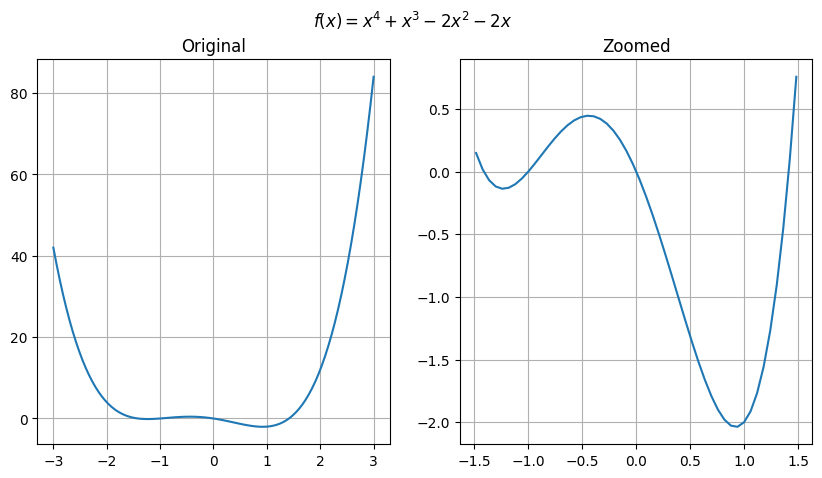

In [18]:
f_name = '$f(x) = x^4 + x^3 -2x^2 -2x$'

def f(x):
    return x**4 + x**3  -2*(x**2) - 2*x
def grad_f(x):
    return 4*(x**3) + 3*(x**2)  -4*x - 2

# Plot function f
x = np.linspace(-3, 3, 100)
y = f(x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(r'$f(x) = x^4 + x^3 -2x^2 -2x$')

ax1.plot(x,y)
ax1.set_title('Original')
ax1.grid()

idx_interesting = (x > -1.5) & (x < 1.5)
ax2.plot(x[idx_interesting],y[idx_interesting])
ax2.set_title('Zoomed')
ax2
ax2.grid()

plt.show()

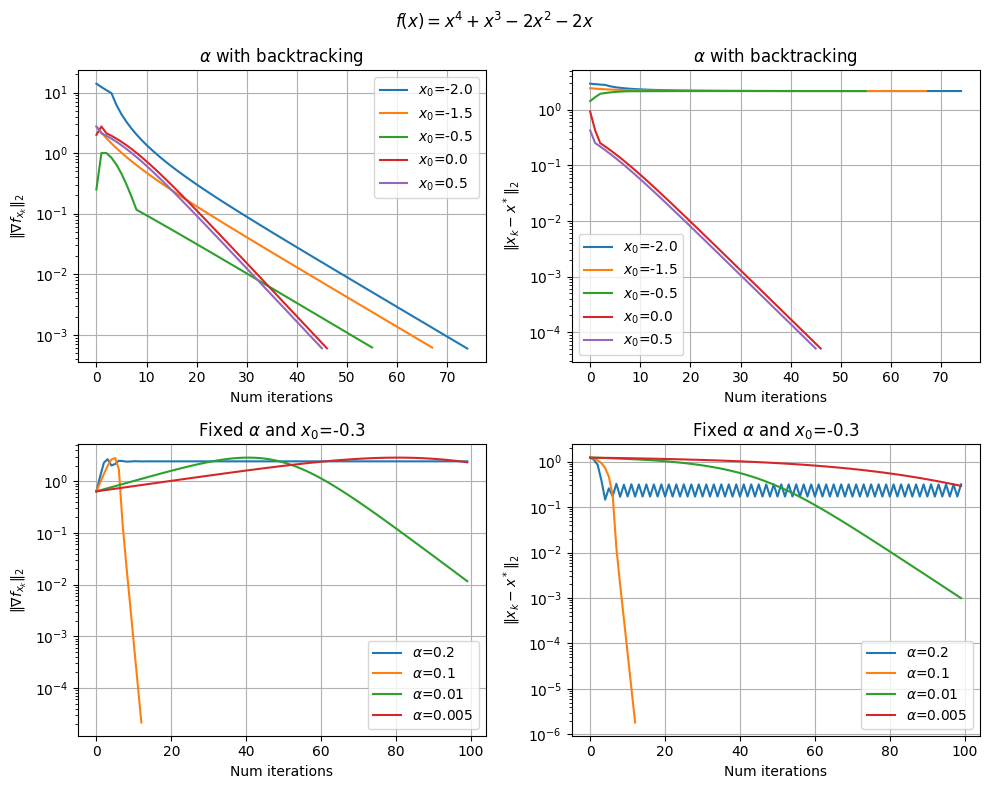

In [19]:
kmax = 100
tolf = tolx = 1e-5
cols = 2
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(10, 8))
axes = axes.flatten()
fig.suptitle(f_name)

#### WITH BACKTRACKING ##########################################################
x0s = np.array([-2, -1.5, -0.5, 0, 0.5])
x_true = 0.9222247929324218857020815

for i, x0 in enumerate(x0s):
    x, k, f_val, grads, err = one_dim_GD(f, grad_f, x0, kmax, tolx, tolf)
    # plot_without_x_true(f_name, x[-1], err, k, ax=axes[i], label=rf"$x_0$={x0}")
    plot_gradient_norm_and_xtrue(
        x, x[-1], err, k, x_true, 
        one_dim=True, 
        title1=r"$\alpha$ with backtracking",
        label1=rf"$x_0$={x0}", ax1=axes[0],
        title2=r"$\alpha$ with backtracking",
        label2=rf"$x_0$={x0}", ax2=axes[1]
    ) 

#### WITHOUT BACKTRACKING #######################################################
x0 = -0.3
alphas = (0.2, 0.1, 0.01, 0.005)

for i, alpha in enumerate(alphas):
    x, k, f_val, grads, err = one_dim_GD(f, grad_f, x0, kmax, tolx, tolf, alpha=alpha)
    # plot_without_x_true(f_name, x[-1], err, k, alpha=alpha, ax=axes[i], label=rf"$\alpha$={alpha}")
    plot_gradient_norm_and_xtrue(
        x, x[-1], err, k, x_true,
        one_dim=True, 
        title1=rf"Fixed $\alpha$ and $x_0$={x0}",
        label1=rf"$\alpha$={alpha}", ax1=axes[2],
        title2=rf"Fixed $\alpha$ and $x_0$={x0}",
        label2=rf"$\alpha$={alpha}", ax2=axes[3]
    )
    
plt.tight_layout()
plt.show()

We can notice that when we start before the local maxima $x^* \approx -0.4399$ our search gets stuck in the local minima $x^* \approx -1.2322$ while if we start right after then our search proceeds correctly (if we use backtracking or reasonable fixed learning rates wrt the $x_0$)


# 2) Optimization via Stochastic Gradient Descent

## 2.1) Consider the dataset `poly_regression_large.csv`, provided on Virtuale.

(1000,) (1000,)


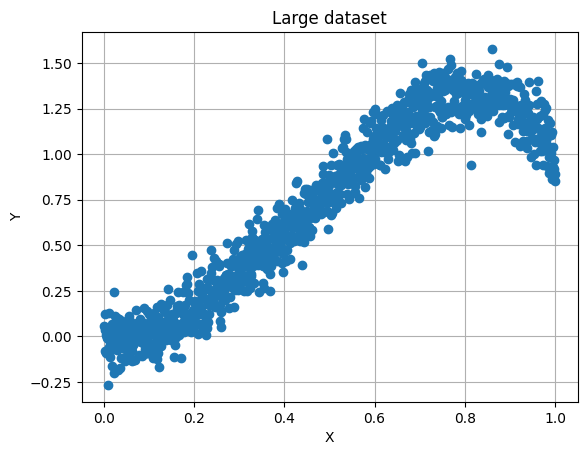

In [3]:
import pandas as pd

# Extract the dataset
data = pd.read_csv('./poly_regression_large.csv', index_col=0)
X = np.array(data["x"])
Y = np.array(data["y"])
print(X.shape, Y.shape)

# Visualize dataset
plt.plot(X,Y, 'o')
plt.title("Large dataset")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

## 2.2) Let $f_\theta(x)$ be a polynomial regression model, as discussed in [regression lab lesson](https://devangelista2.github.io/statistical-mathematical-methods/regression_classification/regression.html)

In [4]:
def vandermonde(x, K):
    N = x.shape[0]
    Phi = np.ones((K, N))
    for i in range(1, K):
        Phi[i, :] = x**i
    return Phi

def f(x, theta):
    K = theta.shape[0]
    Phi = vandermonde(x, K)
    return Phi.T @ theta

def loss_function(x, y, theta):
    return 0.5 * np.sum((f(x, theta) - y)**2) / len(y)

def grad_loss(x, y, theta):
    K = theta.shape[0]
    Phi = vandermonde(x, K)
    return Phi @ (f(x, theta) - y) / len(y)

## 2.3) Split the dataset into training and test set as in the Homework 2, with a proportion of 80% training and 20% test.

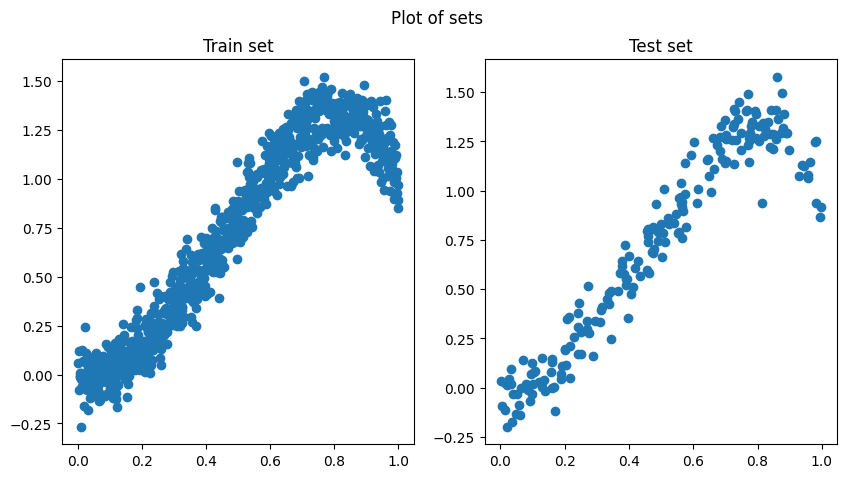

In [5]:
def train_test_split (X, Y, N, perc) :
    idx = np.arange(0, N)
    np.random.shuffle(idx)

    idx_train = int(perc*N)

    train_idx = idx[:idx_train]
    test_idx = idx[idx_train:]

    X_train = X[train_idx]
    Y_train = Y[train_idx]

    X_test = X[test_idx]
    Y_test = Y[test_idx]
    return X_train, X_test, Y_train, Y_test


X_train, X_test, Y_train, Y_test = train_test_split(X, Y, X.shape[0], 0.80)
# print(X_train.shape, X_test.shape)
# print(Y_train.shape, Y_test.shape)

# Plot the sets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Plot of sets")

ax1.set_title("Train set")
ax1.plot(X_train, Y_train, 'o')

ax2.set_title("Test set")
ax2.plot(X_test, Y_test, 'o')

plt.show()


## 2.4) Fix a degree $K$ for the polynomial.

In [6]:
K = 4

## 2.5) Train the polynomial regression model on the training set via the Stochastic Gradient Descent algorithm.

In [7]:
def SGD(loss, grad_loss, D, theta0, alpha=0.01, batch_size=16, n_epochs=100):
    X, y = D  # Unpack the data
    N = X.shape[0]  # Number of samples
    d = theta0.shape[0]  # Number of parameters in theta
    idx = np.arange(N)  # Index array for shuffling

    # History vectors
    theta_history = np.zeros((n_epochs, d))
    loss_history = np.zeros(n_epochs)
    grad_norm_history = np.zeros(n_epochs)

    # Initialize parameters
    theta = theta0
    for epoch in range(n_epochs):
        # Shuffle the data
        np.random.shuffle(idx)
        X_shuffled = X[idx]
        y_shuffled = y[idx]

        grad_loss_vec = []
        for batch_start in range(0, N, batch_size):
            batch_end = min(batch_start + batch_size, N)
            X_batch = X_shuffled[batch_start:batch_end]
            y_batch = y_shuffled[batch_start:batch_end]

            # Compute gradient
            gradient = grad_loss(X_batch, y_batch, theta)
            grad_loss_vec.append(np.linalg.norm(gradient, 2))

            # Update theta
            theta = theta - alpha * gradient

        # Save history
        theta_history[epoch] = theta
        loss_history[epoch] = loss(X, y, theta)
        grad_norm_history[epoch] = np.mean(grad_loss_vec)

    return theta_history, loss_history, grad_norm_history


In [8]:
# theta0 = np.random.randn(K)
theta0 = np.zeros(K)
theta_history, loss_history, grad_norm_history = SGD(
    loss_function, grad_loss, 
    (X_train, Y_train), theta0
)
theta_final_SGD_on_train = theta_history[-1]
print(theta_final_SGD_on_train)

[ 0.06791283  1.02077532  0.46992734 -0.01378752]


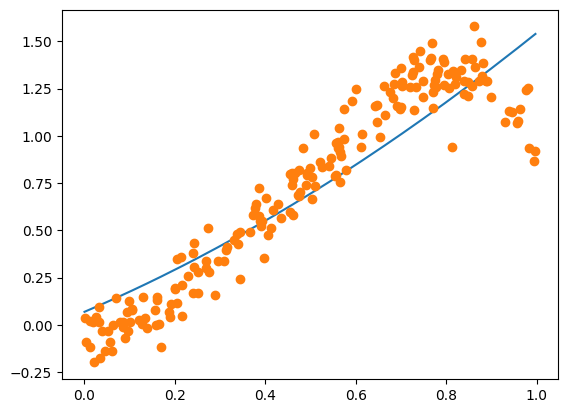

In [9]:
# Just to test
idx_sorted = np.argsort(X_test)
plt.plot(X_test[idx_sorted], f(X_test, theta_final_SGD_on_train)[idx_sorted])
plt.plot(X_test, Y_test, 'o')
plt.show()

## 2.6) Train the polynomial regression model on the training set via the Gradient Descent algorithm.

In [10]:
def backtracking_regression(f, grad_f, X_train, Y_train, theta):
    alpha = 1
    c = 0.8
    tau = 0.25
    
    while f(X_train, Y_train, theta - alpha * grad_f(X_train, Y_train, theta)) > f(X_train, Y_train, theta) - c * alpha * np.linalg.norm(grad_f(X_train, Y_train, theta), 2) ** 2:
        alpha = tau * alpha
        
        if alpha < 1e-3:
            break
    return alpha

In [11]:
def GD_regression(
       loss_f,                      # Function we want to optimize
       grad_loss,                   # Gradient
       theta0,                      # Starting point
       D,                           # Train dataset
       kmax,                        # Maximum number of iterations
       tolx,                        # The relative tolerance of the algorithm
       tolf,                        # The tolerance for the gradient norm
       alpha=None                   # Learning rate (optional)
    ) -> tuple:

    X_train, Y_train = D
    
    # If alpha is not given we backtrack
    backtracking_enabled = (alpha is None)
    
    # Iniizialize the containers
    thetas, f_val, grads = [], [], []
    
    # Pass actual value to next iteration
    theta_old = theta0
    
    for k in range(kmax):
        # Update containers
        thetas.append(theta_old)
        f_val.append(loss_f(X_train, Y_train, theta_old))
        grads.append(grad_loss(X_train, Y_train, theta_old))
        
        # Compute backtracking
        if backtracking_enabled: 
            alpha = backtracking_regression(loss_f, grad_loss, X_train, Y_train, theta_old)
        
        # Compute the new value
        theta = theta_old - alpha * grad_loss(X_train, Y_train, theta_old)
        
        # Check the stop condition
        if np.linalg.norm(grad_loss(X_train, Y_train, theta), 2) <= tolf * np.linalg.norm(grad_loss(X_train, Y_train, theta0), 2):
            break
        if np.linalg.norm(theta - theta_old, 2) <= tolx:
            break
        
        # Pass actual value to next iteration
        theta_old = theta
    
    return np.array(thetas), k+1, np.array(f_val), np.array(grads)

In [12]:
# theta0 = np.random.randn(K)
theta0 = np.zeros(K)
theta_history, num_iterations, loss_history, grad_norm_history = GD_regression(
    loss_function, grad_loss, 
    theta0, (X_train, Y_train),
    kmax=100,
    tolx=1e-5,
    tolf=1e-5
)
theta_final_GD_on_train_backtracking = theta_history[-1]
print(theta_final_GD_on_train_backtracking)
print(f"Used {num_iterations} iterations")

[-0.01337036  1.34178782  0.45695456 -0.31866229]
Used 100 iterations


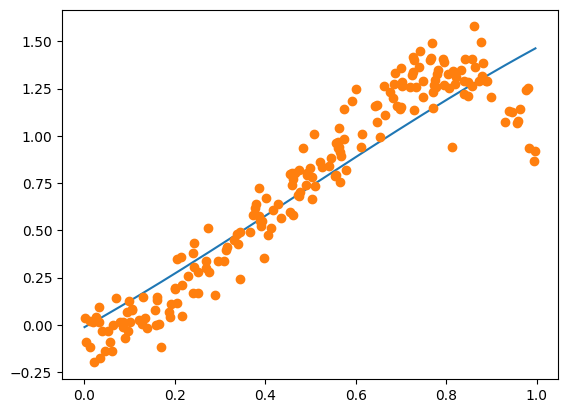

In [13]:
# Just to test
idx_sorted = np.argsort(X_test)
plt.plot(X_test[idx_sorted], f(X_test, theta_final_GD_on_train_backtracking)[idx_sorted])
plt.plot(X_test, Y_test, 'o')
plt.show()

## 2.7) Train the polynomial regression model on the `poly_regression_small.csv` dataset. Use the full dataset for this test, without splitting it into training and test set. 

NOTE: i interpreted that the "3 model" to show were instead 4 (SGD and GD trained both on $(X_{train}, Y_{train})$ and $(X_{small}, Y_{small}$)

In [14]:
data = pd.read_csv('./poly_regression_small.csv', index_col=0)
X_small = np.array(data["x"])
Y_small = np.array(data["y"])

In [15]:
# theta0 = np.random.randn(K)
theta0 = np.zeros(K)

# SGD on small
theta_history, loss_history, grad_norm_history = SGD(
    loss_function, grad_loss, 
    (X_small, Y_small), theta0
)
theta_final_SGD_on_small = theta_history[-1]

# GD on small
theta_history, num_iterations, loss_history, grad_norm_history = GD_regression(
    loss_function, grad_loss, 
    theta0, (X_small, Y_small),
    kmax=100,
    tolx=1e-5,
    tolf=1e-5
)
theta_final_GD_on_small_backtracking = theta_history[-1]

#### In order to correctly compare GD with fixed alpha, we chose the default one fro SGD 
alpha = 0.01

# GD on small (fixed alpha)
theta_history, num_iterations, loss_history, grad_norm_history = GD_regression(
    loss_function, grad_loss, 
    theta0, (X_small, Y_small),
    kmax=100,
    tolx=1e-5,
    tolf=1e-5,
    alpha=alpha
)
theta_final_GD_on_small_fixed = theta_history[-1]

# GD on train (fixed alpha)
theta_history, num_iterations, loss_history, grad_norm_history = GD_regression(
    loss_function, grad_loss, 
    theta0, (X_train, Y_train),
    kmax=100,
    tolx=1e-5,
    tolf=1e-5,
    alpha=alpha
)
theta_final_GD_on_train_fixed = theta_history[-1]

## 2.8) Compare the performance of the three regression model computed above. 

In particular, if $(X_{test}, Y_{test})$ is the test set from the `poly_regression_large.csv` dataset, for each of the model, compute:

**$$ Err = \frac{1}{N_{test}}\sum_{i=1}^{N_{test}}(f_\theta(x^i)-y^i)^2$$**

where $N_{test}$ is the number of elements in the test set, $(x^i, y^i)$ are the input and output elements in the test set. Comment the performance of the three models.

In [16]:
def err(X,Y, model_theta):
    return np.mean(np.square(f(X, model_theta) - Y))

In [19]:
models = {
    "SGD_train": theta_final_SGD_on_train,
    "SGD_small": theta_final_SGD_on_small,
    "GD_train_backtracking": theta_final_GD_on_train_backtracking,
    "GD_small_backtracking": theta_final_GD_on_small_backtracking,
    "GD_train_fixed": theta_final_GD_on_train_fixed,
    "GD_small_fixed": theta_final_GD_on_small_fixed,
}

errors = {
    model: err(X_test, Y_test, params) for model, params in models.items()
}

df = pd.DataFrame(errors.items(), columns=["Model", "Error"])
df_sorted = df.sort_values(by="Error", ascending=True)
df_sorted

,Model,Error
3,GD_small_backtracking,0.027928
2,GD_train_backtracking,0.028398
0,SGD_train,0.037518
1,SGD_small,0.075338
4,GD_train_fixed,0.140885
5,GD_small_fixed,0.143395


As we could expect, the error on the SGD with the smaller dataset is higher since the SGD has used batches with very few data and so those batch are not representative of the dataset anymore. The representativeness of the data in the batches of the SGD is a fundamental assumption for it to work correctly.

## 2.9) Repeat the experiment by varying the degree $K$ of the polynomial. Comment the results.

In [35]:

from numpy.linalg import LinAlgError

def generalized_experiment(
        K, 
        loss_function, 
        grad_loss, 
        X_train,Y_train,
        X_test,Y_test,
        X_small,Y_small
    ):
    
    # Starting point (the same for all)
    # theta0 = np.random.randn(K)
    theta0 = np.zeros(K)
    
    # Parameters
    alpha = 0.5
    kmax = n_epochs = 100
    
    # SGD (train dataset)
    theta_history, _, _ = SGD(
        loss_function, grad_loss, 
        (X_train, Y_train), theta0,
        alpha=alpha,
        n_epochs=n_epochs,
        batch_size = X_train.shape[0] // 15
    )
    theta_final_SGD_on_train = theta_history[-1]
    
    # SGD (small dataset)
    theta_history, _, _ = SGD(
        loss_function, grad_loss, 
        (X_small, Y_small), theta0,
        alpha=alpha,
        n_epochs=n_epochs,
        batch_size = X_small.shape[0] // 15
    )
    theta_final_SGD_on_small = theta_history[-1]
    
    # GD (train dataset + backtracking)
    theta_history, _, _, _ = GD_regression(
        loss_function, grad_loss, 
        theta0, (X_train, Y_train),
        kmax=kmax,
        tolx=1e-5,
        tolf=1e-5
    )
    theta_final_GD_on_train_backtracking = theta_history[-1]
    
    # GD (small dataset + backtracking)
    theta_history, _, _, _ = GD_regression(
        loss_function, grad_loss, 
        theta0, (X_train, Y_train),
        kmax=kmax,
        tolx=1e-5,
        tolf=1e-5
    )
    theta_final_GD_on_small_backtracking = theta_history[-1]
    
    # GD (train dataset + fixed)
    theta_history, _, _, _ = GD_regression(
        loss_function, grad_loss, 
        theta0, (X_train, Y_train),
        kmax=kmax,
        tolx=1e-5,
        tolf=1e-5,
        alpha=alpha
    )
    theta_final_GD_on_train_fixed = theta_history[-1]
    
    # GD (small dataset + fixed)
    theta_history, _, _, _ = GD_regression(
        loss_function, grad_loss, 
        theta0, (X_train, Y_train),
        kmax=kmax,
        tolx=1e-5,
        tolf=1e-5,
        alpha=alpha
    )
    theta_final_GD_on_small_fixed = theta_history[-1]
        
    # Error
    errors = {}
    models = {
        "SGD_train" : theta_final_SGD_on_train, 
        "SGD_small" : theta_final_SGD_on_small, 
        "GD_train_backtracking" : theta_final_GD_on_train_backtracking, 
        "GD_small_backtracking" : theta_final_GD_on_small_backtracking, 
        "GD_train_fixed" : theta_final_GD_on_train_fixed, 
        "GD_small_fixed" : theta_final_GD_on_small_fixed, 
    }

    for k,v in models.items():
        errors[k] = err(X_test, Y_test, v)
    
    return models, errors

K progress: 25it [01:09,  2.77s/it]


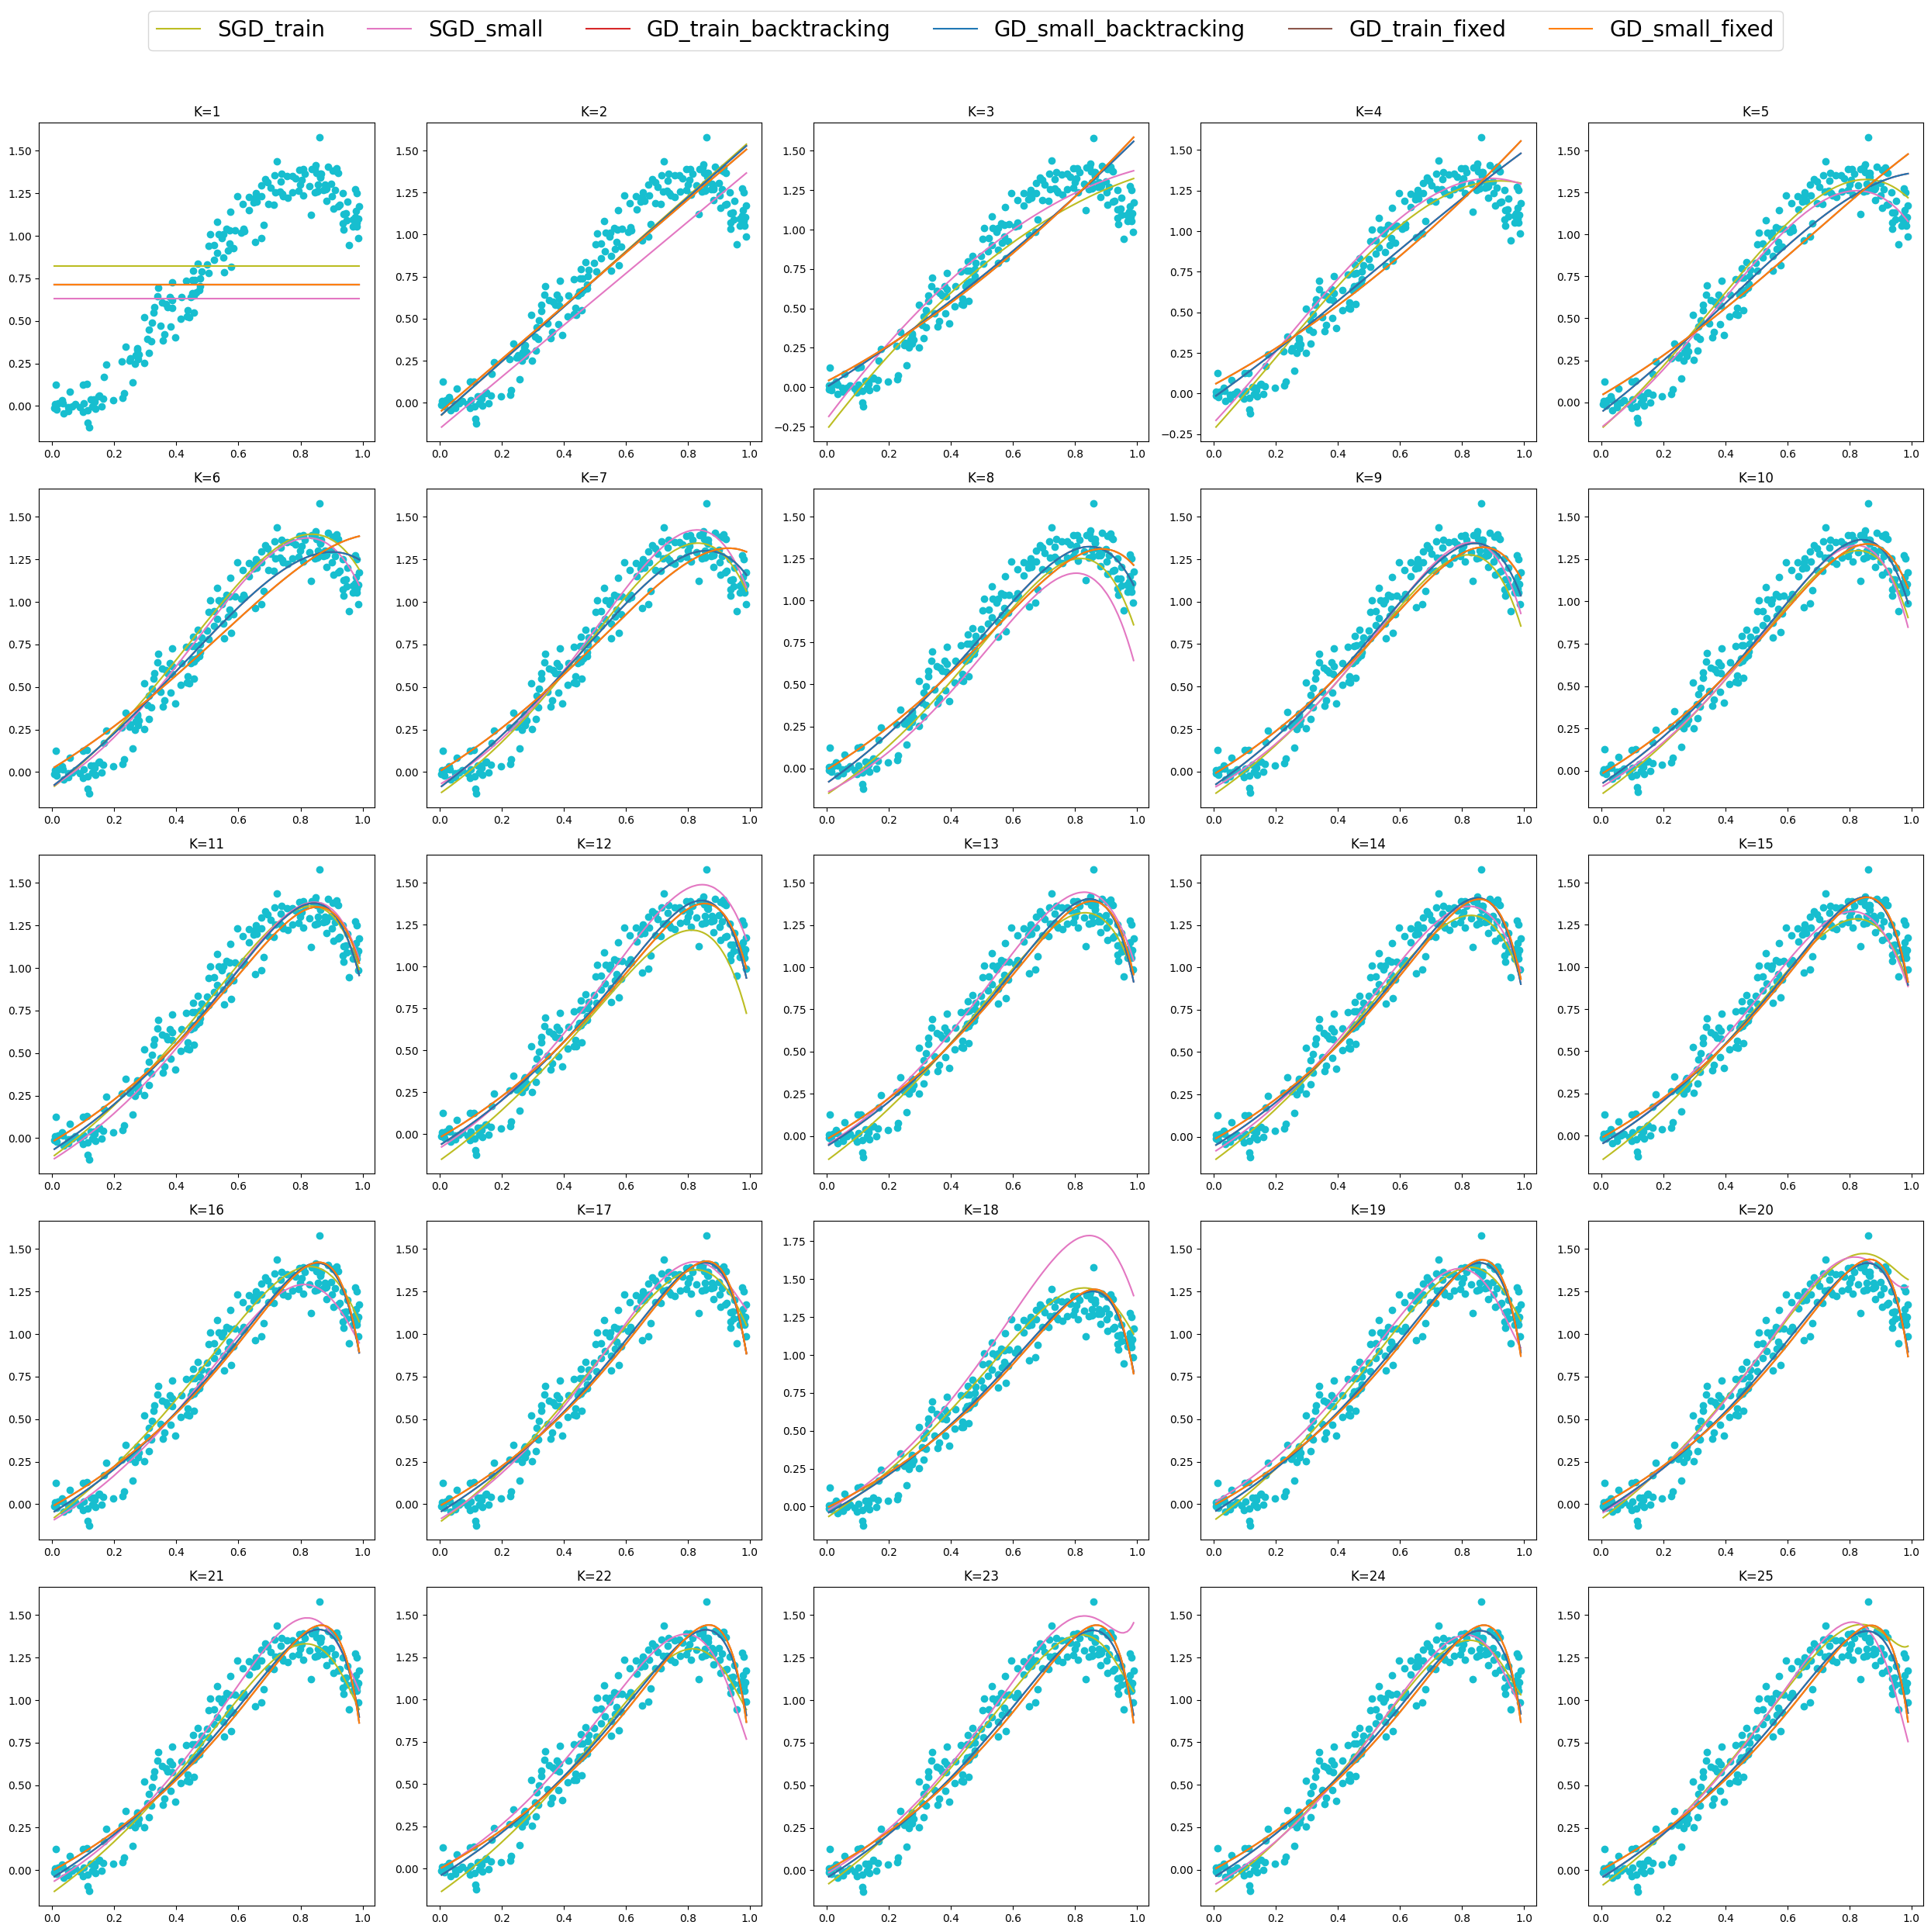

In [36]:
from tqdm import tqdm
from matplotlib import colormaps

Ks = [*range(1,26)] #+ np.linspace(6, 25, 4, dtype=int).tolist()

cmap = colormaps["tab10"] # 'tab10', 'viridis', 'plasma'
colors = {k: cmap(i / len(models.keys())) for i, k in enumerate(sorted(list(models.keys()) + ["data"]))}

data_large = pd.read_csv('./poly_regression_large.csv', index_col=0)
X_large = np.array(data_large["x"])
Y_large = np.array(data_large["y"])

data_small = pd.read_csv('./poly_regression_small.csv', index_col=0)
X_small = np.array(data_small["x"])
Y_small = np.array(data_small["y"])

X_train, X_test, Y_train, Y_test = train_test_split(
    X_large, Y_large, 
    X_large.shape[0], 
    perc=0.8
)

errors_list = { k:[] for k in models.keys() }

# Obtain a square grid of subplots
n = len(Ks)
cols = int(np.ceil(np.sqrt(n)))  
rows = int(np.ceil(n / cols))    
fig, axes = plt.subplots(rows, cols, figsize=(n,n))
axes = axes.flatten()

for i, K in tqdm(enumerate(Ks), desc="K progress"):
    
    # Run experiment
    theta_models, errors = generalized_experiment(
        K,
        loss_function, grad_loss,
        X_train, Y_train, 
        X_test, Y_test, 
        X_small, Y_small
    )
    
    # Fill the K-th subplot
    axes[i].set_title(f"K={K}")
    axes[i].plot(X_test, Y_test, 'o', color=colors["data"])
    idx_sorted = np.argsort(X_test)
    
    for k in errors:
        errors_list[k].append(errors[k])
        axes[i].plot(X_test[idx_sorted], f(X_test, theta_models[k])[idx_sorted], label=k, color=colors[k])
    
    if i==0 : handles, labels = axes[i].get_legend_handles_labels()

# Plot the subplots
fig.legend(handles, labels, loc='upper center', fontsize=20, ncol=len(errors_list))
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


- As $K$ increases, the models use higher-degree polynomials to fit the data. This results in increasingly complex curves, which can better capture the training data but also lead to overfitting, especially for the small dataset.

- The $SGD_{\text{small}}$ visibly struggles to generalize the test data, particularly for higher $K$. The predictions deviate significantly from the true function, indicating poor performance.

- $SGD_{\text{train}}$, $GD_{\text{train}}$, $GD_{\text{small}}$ exhibit greater robustness across all $K$. They adapt reasonably well to the increasing polynomial degree, maintaining relatively consistent performance on the test data without drastic deviations.

- $GD_{\text{train\_backtr}}$, $GD_{\text{small\_backtr}}$ show a tendency to overfit as $K$ increases. This is evident from their exaggerated fits for larger $K$, particularly in the test set regions with sparse data.

- Across the subplots, as $K$ grows, the models trained on larger datasets (train) consistently outperform those trained on the small dataset (small). This underscores the importance of data size in mitigating overfitting and ensuring better generalization.

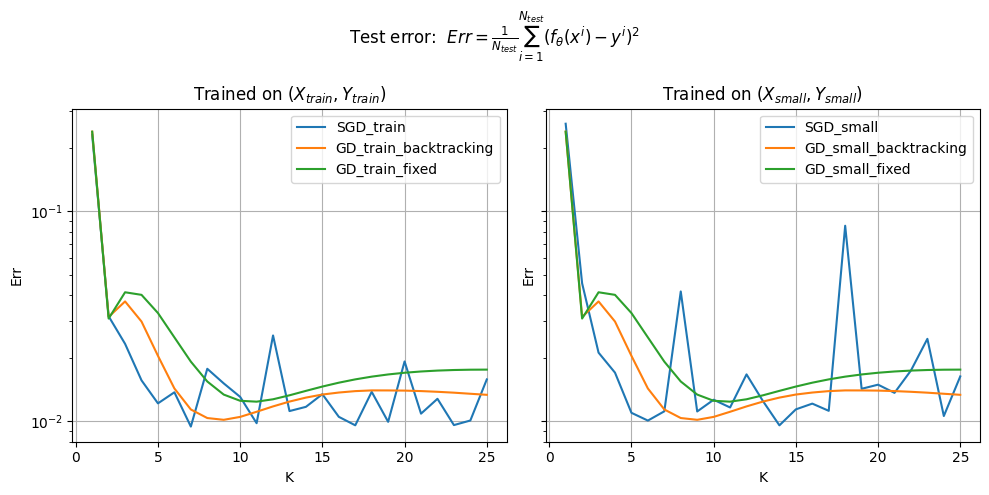

In [37]:
fig, axes = plt.subplots(1, 2, figsize=[10, 5], sharey=True)
fig.suptitle(r"Test error:  $Err = \frac{1}{N_{test}}\sum_{i=1}^{N_{test}}(f_\theta(x^i)-y^i)^2$")

axes[0].set_title("Trained on $(X_{train}, Y_{train})$")
axes[1].set_title("Trained on $(X_{small}, Y_{small})$")

for k in errors_list:
    if k.__contains__("small"):
        axes[1].plot(Ks, errors_list[k], label=k)
    else:
        axes[0].plot(Ks, errors_list[k], label=k)

for ax in axes:
    ax.set_xlabel("K")
    ax.set_yscale("log")
    ax.set_ylabel("Err")
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()


- Of course, all the model perfomed worse at the first $K$. High polynomial complexity allows the model to better fit the data because it provides more flexibility to capture non-linear patterns and variations in the dataset. Conversely, low polynomial complexity limits the model's ability to adapt to the data, forcing it to approximate the relationship with overly simple linear or low-degree patterns, which leads to underfitting.

- $SGD_{\text{train}}$ consistently achieves the lowest test error across all $K$. It demonstrates excellent robustness, particularly for higher $K$, where its error remains stable and does not increase significantly.

- $SGD_{\text{small}}$ shows the highest test error throughout most of the $K$ range. The fluctuations in error, especially for higher $K$, suggest that the smaller dataset is insufficient for training complex models, leading to poor generalization. Especially, in the case of the SGD, a poor dataset is even worse, since it makes the batches less representative of the dataset and so the ...

- $GD_{\text{train\_fixed}}$, $GD_{\text{small\_fixed}}$ follow a similar pattern (but constantly higher) to their backtracking counterparts but seem slightly more stable for higher $K$.

- $GD_{\text{train\_backtr}}$, $GD_{\text{small\_backtr}}$ display moderate performance. They benefit from backtracking for low $K$ (reducing error) but show signs of overfitting or inability to generalize for higher $K$, where their error starts increasing gradually.

## 2.10) Set $K=5$ (so that the polynomial regression model is a polynomial of degree 4). 
Compare the parameters learned by the three models with the true parameter 
$\theta^*=[0,0,4,0,-3]$

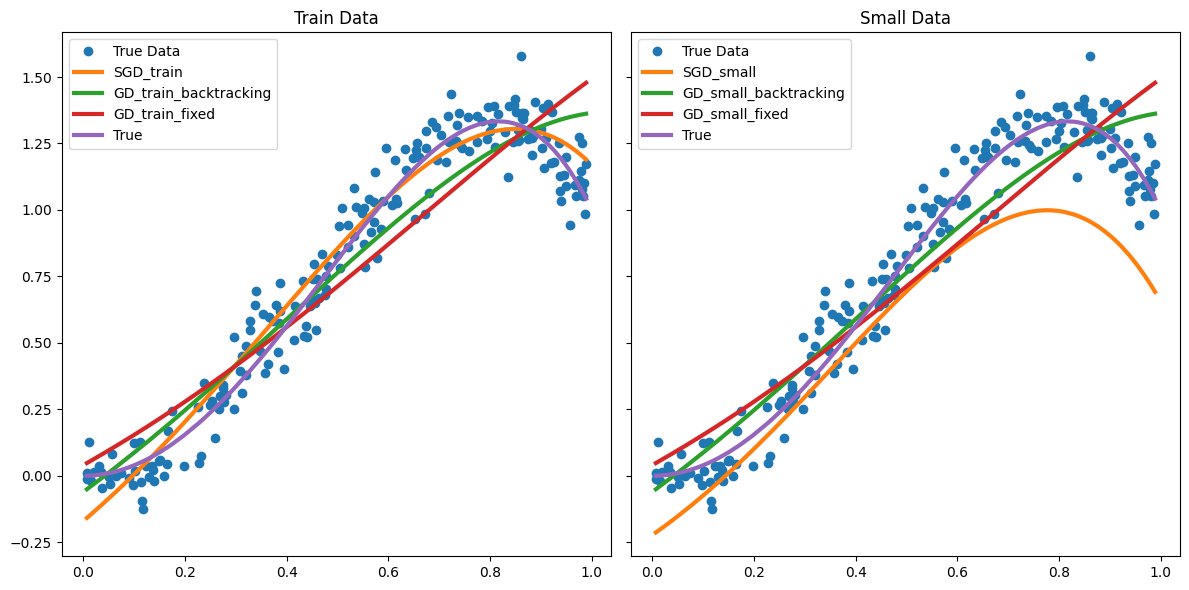

,Model,Normalized Error
6,True,1.000000
0,SGD_train,1.290479
3,GD_small_backtracking,2.323626
2,GD_train_backtracking,2.323626
5,GD_small_fixed,3.717002
4,GD_train_fixed,3.717002
1,SGD_small,7.521474


In [38]:
theta_true = np.array([0,0,4,0,-3])

K=5
theta_models, errors = generalized_experiment(
    K,
    loss_function, grad_loss,
    X_train, Y_train, 
    X_test, Y_test, 
    X_small, Y_small
)

# Compare the results
idx_sorted = np.argsort(X_test)
theta_models["True"] = theta_true
errors["True"] = err(X_test, Y_test, theta_true)

fig, axes = plt.subplots(1, 2, figsize=[12, 6], sharey=True)

# Plot for the "train" data
axes[0].plot(X_test, Y_test, 'o', label="True Data")
for k in theta_models:
    if "train" in k:
        axes[0].plot(X_test[idx_sorted], f(X_test, theta_models[k])[idx_sorted], label=k, linewidth=3)
axes[0].set_title("Train Data")

# Plot for the "small" data
axes[1].plot(X_test, Y_test, 'o', label="True Data")
for k in theta_models:
    if "small" in k:
        axes[1].plot(X_test[idx_sorted], f(X_test, theta_models[k])[idx_sorted], label=k, linewidth=3)
axes[1].set_title("Small Data")

for ax in axes :
    ax.plot(X_test[idx_sorted], f(X_test, theta_models["True"])[idx_sorted], label="True", linewidth=3)
    ax.legend()

# Adjust layout
plt.tight_layout()
plt.show()

# Print errors (normalized wrt the True regressor to give and idea of the distance from the real solution)
normalized_errors = {k: v / errors['True'] for k, v in errors.items()}
df_errors = pd.DataFrame(list(normalized_errors.items()), columns=["Model", "Normalized Error"]).sort_values(by="Normalized Error", ascending=True)
display(df_errors)
